In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [1]:
df = pd.read_csv("ispark_parking.csv")
print("Ham veri:", df.shape)

# Derste tespit ettiğimiz gizli hata: -99 koordinatlı satırlar (sentinel değerler)
df = df[(df["LATITUDE"] > 30) & (df["LONGITUDE"] > 20)].copy()

# Ek kontrol: kapasitesi 0 olan kayıt mantıksal hata sayılır (park yeri 0 araç alamaz)
print("Kapasitesi 0 olan satır:", (df["CAPACITY_OF_PARK"] == 0).sum())
df = df[df["CAPACITY_OF_PARK"] > 0].copy()

print("Temiz veri:", df.shape)

Ham veri: (708, 9)
Kapasitesi 0 olan satır: 1
Temiz veri: (703, 9)


In [2]:
# Dummy değişken: 24 Saat çalışıyorsa 1, değilse 0
df["IS_24H"] = (df["WORKING_TIME"] == "24 Saat").astype(int)

print(df["IS_24H"].value_counts())
print()
# İki grubun kapasite istatistikleri (regresyon öncesi ön izleme)
df.groupby("IS_24H")["CAPACITY_OF_PARK"].agg(["count", "mean", "median", "std"]).round(1)

IS_24H
0    509
1    194
Name: count, dtype: int64



,count,mean,median,std
IS_24H,,,,
0,509,104.2,40.0,444.8
1,194,408.5,250.0,508.3


In [3]:
# --- Regresyonu SIFIRDAN hesaplıyoruz (dersteki formüllerle) ---
x = df["IS_24H"].values.astype(float)
y = df["CAPACITY_OF_PARK"].values.astype(float)

b1 = np.sum((x - x.mean()) * (y - y.mean())) / np.sum((x - x.mean())**2)
b0 = y.mean() - b1 * x.mean()

print(f"b0 (intercept) = {b0:.2f}")
print(f"b1 (slope)     = {b1:.2f}")
print(f"Denklem: ŷ = {b0:.1f} + {b1:.1f}·x")

b0 (intercept) = 104.21
b1 (slope)     = 304.24
Denklem: ŷ = 104.2 + 304.2·x


In [4]:
# Model gücü: R² (dersteki gibi elle)
y_pred = b0 + b1 * x
ss_res = np.sum((y - y_pred)**2)    # açıklanamayan varyans
ss_tot = np.sum((y - y.mean())**2)  # toplam varyans
r2 = 1 - ss_res / ss_tot
print(f"R² = {r2:.4f}")

# scipy ile doğrulama
s = stats.linregress(x, y)
print(f"scipy -> slope={s.slope:.2f}, intercept={s.intercept:.2f}, R²={s.rvalue**2:.4f}, p={s.pvalue:.2e}")

R² = 0.0796
scipy -> slope=304.24, intercept=104.21, R²=0.0796, p=2.50e-14


In [5]:
# groupby ile ilçe bazlı özet tablo oluşturuyoruz (her ilçe = 1 gözlem)
ilce = df.groupby("COUNTY_NAME").agg(
    Park_Sayisi=("PARK_NAME", "count"),
    Toplam_Kapasite=("CAPACITY_OF_PARK", "sum"),
).reset_index()

print("İlçe sayısı:", len(ilce))
ilce.sort_values("Park_Sayisi", ascending=False).head(8)

İlçe sayısı: 34


,COUNTY_NAME,Park_Sayisi,Toplam_Kapasite
15,FATİH,113,14147
33,ŞİŞLİ,65,4629
11,BEŞİKTAŞ,64,3546
18,KADIKÖY,57,8047
4,BAKIRKÖY,37,5615
10,BEYOĞLU,37,6430
23,PENDİK,31,5334
24,SARIYER,27,12422


In [6]:
# --- Sürekli değişkenli regresyon: yine SIFIRDAN ---
x2 = ilce["Park_Sayisi"].values.astype(float)
y2 = ilce["Toplam_Kapasite"].values.astype(float)

b1_2 = np.sum((x2 - x2.mean()) * (y2 - y2.mean())) / np.sum((x2 - x2.mean())**2)
b0_2 = y2.mean() - b1_2 * x2.mean()

y2_pred = b0_2 + b1_2 * x2
r2_2 = 1 - np.sum((y2 - y2_pred)**2) / np.sum((y2 - y2.mean())**2)

print(f"Denklem: Toplam_Kapasite = {b0_2:.1f} + {b1_2:.1f} · Park_Sayisi")
print(f"R² = {r2_2:.4f}")

# scipy doğrulaması
s2 = stats.linregress(x2, y2)
print(f"scipy -> slope={s2.slope:.2f}, intercept={s2.intercept:.2f}, R²={s2.rvalue**2:.4f}, p={s2.pvalue:.2e}")

Denklem: Toplam_Kapasite = 1785.0 + 101.8 · Park_Sayisi
R² = 0.3710
scipy -> slope=101.84, intercept=1785.03, R²=0.3710, p=1.32e-04


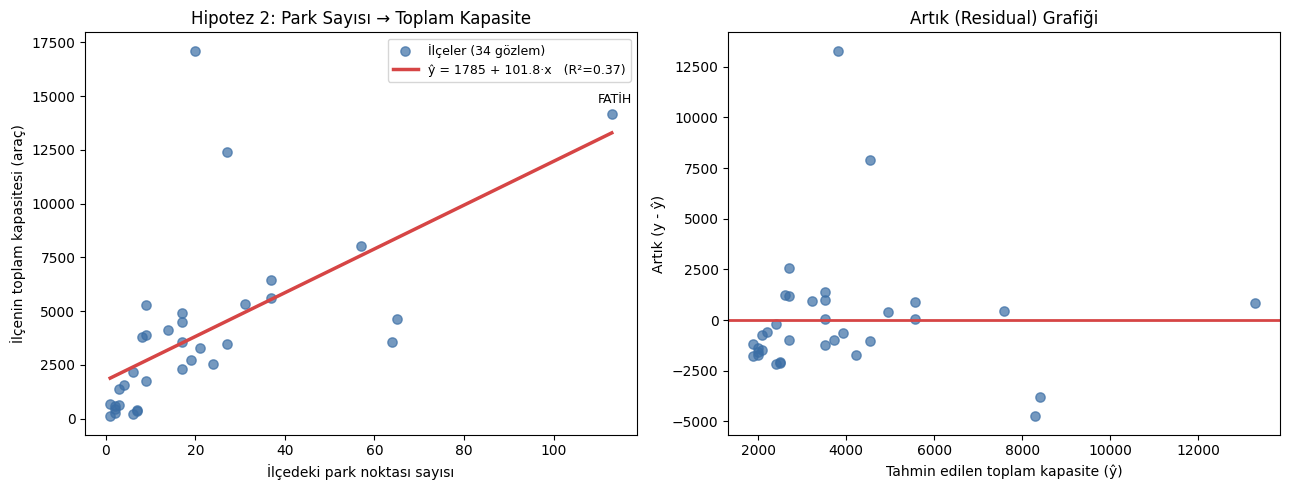

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Sol: Hipotez 2'nin regresyon doğrusu ---
ax = axes[0]
ax.scatter(x2, y2, alpha=0.7, s=45, color="#3b6ea5", label="İlçeler (34 gözlem)")
xs = np.linspace(x2.min(), x2.max(), 100)
ax.plot(xs, b0_2 + b1_2 * xs, color="#d64545", linewidth=2.5,
        label=f"ŷ = {b0_2:.0f} + {b1_2:.1f}·x   (R²={r2_2:.2f})")

# En uç ilçeyi etiketleyelim (en çok parkı olan)
en_buyuk = ilce.loc[ilce["Park_Sayisi"].idxmax()]
ax.annotate(en_buyuk["COUNTY_NAME"],
            (en_buyuk["Park_Sayisi"], en_buyuk["Toplam_Kapasite"]),
            textcoords="offset points", xytext=(-10, 8), fontsize=9)

ax.set_xlabel("İlçedeki park noktası sayısı")
ax.set_ylabel("İlçenin toplam kapasitesi (araç)")
ax.set_title("Hipotez 2: Park Sayısı → Toplam Kapasite")
ax.legend(fontsize=9)

# --- Sağ: Hipotez 2'nin artık grafiği ---
resid2 = y2 - y2_pred
ax2 = axes[1]
ax2.scatter(y2_pred, resid2, alpha=0.7, s=45, color="#3b6ea5")
ax2.axhline(0, color="#d64545", linewidth=2)
ax2.set_xlabel("Tahmin edilen toplam kapasite (ŷ)")
ax2.set_ylabel("Artık (y - ŷ)")
ax2.set_title("Artık (Residual) Grafiği")

plt.tight_layout()
plt.show()

In [8]:
karsilastirma = pd.DataFrame({
    "Model": ["H1: 7/24 açık mı? (dummy)", "H2: İlçe park sayısı (sürekli)"],
    "b0": [round(b0, 1), round(b0_2, 1)],
    "b1": [round(b1, 1), round(b1_2, 1)],
    "R2": [round(r2, 3), round(r2_2, 3)],
    "p_degeri": [f"{s.pvalue:.1e}", f"{s2.pvalue:.1e}"],
})
karsilastirma

,Model,b0,b1,R2,p_degeri
0,H1: 7/24 açık mı? (dummy),104.2,304.2,0.080,2.5e-14
1,H2: İlçe park sayısı (sürekli),1785.0,101.8,0.371,1.3e-04
